# Oasis Infobyte / Oasis Infotech Internship  
## Level 1 — Task 1: Retail Sales EDA

Welcome to this retail sales exploration. We'll use the dataset to find patterns in sales, customer behavior, and product performance.

**What you need:** a retail/e-commerce CSV file with columns such as:

- Date / Order Date / Invoice Date
- Customer ID
- Gender
- Age
- Product Name or Product Category
- Quantity
- Price per Unit / Sales / Revenue / Total Amount

If your file has a different column name, you can update the matching rules later in the notebook.

Place the CSV file in the same folder as this notebook and update the file name in the next code cell if necessary.

## 1. Import Libraries

Here we load the libraries used for cleaning data, exploring trends, and making charts.

In [46]:
%pip install seaborn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

Note: you may need to restart the kernel to use updated packages.


## 2. Load Dataset and Inspect It

Let's load the file, check the shape and columns, preview the first rows, and spot any missing values.

In [47]:
# Update this file name if your dataset file has a different name
CSV_FILE_NAME = "retail_sales_dataset.csv"

df = pd.read_csv(CSV_FILE_NAME)

print("Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape of dataset: (1000, 9)


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [48]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
missing_values = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})
display(missing_values)

print("\nDuplicate rows:", df.duplicated().sum())

Column names:
['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']

Data types:


Transaction ID      int64
Date                  str
Customer ID           str
Gender                str
Age                 int64
Product Category      str
Quantity            int64
Price per Unit      int64
Total Amount        int64
dtype: object


Missing values:


,Missing Count,Missing Percentage
Transaction ID,0,0.00
Date,0,0.00
Customer ID,0,0.00
Gender,0,0.00
Age,0,0.00
Product Category,0,0.00
Quantity,0,0.00
Price per Unit,0,0.00
Total Amount,0,0.00



Duplicate rows: 0


**Observation:**  
This initial check helps us see the dataset size, the available columns, and whether there are missing or duplicate entries. Fixing issues now makes the analysis more trustworthy.

## 3. Basic Data Cleaning and Column Detection

This step tries to identify the main retail columns automatically, like date, product, quantity, price, and sales. If your file uses different column names, you can add them to the lists below.

In [ ]:
# Remove extra spaces from column names so matching works more reliably
df.columns = df.columns.str.strip()

def find_column(dataframe, candidates, required=True):
    """Find a column in dataframe using a list of possible names."""
    lower_map = {col.lower().strip(): col for col in dataframe.columns}
    for candidate in candidates:
        if candidate.lower().strip() in lower_map:
            return lower_map[candidate.lower().strip()]

    # partial match fallback
    for col in dataframe.columns:
        col_low = col.lower()
        for candidate in candidates:
            if candidate.lower() in col_low:
                return col

    if required:
        raise ValueError(f"Required column not found. Tried: {candidates}\nAvailable columns: {list(dataframe.columns)}")
    return None

date_col = find_column(df, ["Date", "Order Date", "InvoiceDate", "Invoice Date", "Transaction Date", "Purchase Date"])
age_col = find_column(df, ["Age", "Customer Age"], required=False)
gender_col = find_column(df, ["Gender", "Customer Gender", "Sex"], required=False)
category_col = find_column(df, ["Product Category", "Category", "Item Category", "Sub-Category"], required=False)
product_col = find_column(df, ["Product Name", "Product", "Item Purchased", "Description", "Item", "SKU"], required=False)
quantity_col = find_column(df, ["Quantity", "Qty", "Quantity Sold", "Units Sold"], required=False)
price_col = find_column(df, ["Price per Unit", "Unit Price", "Price", "UnitPrice"], required=False)
sales_col = find_column(df, ["Total Amount", "Sales", "Revenue", "Total Price", "Purchase Amount", "Amount"], required=False)

print("Detected columns:")
print("Date column:", date_col)
print("Age column:", age_col)
print("Gender column:", gender_col)
print("Category column:", category_col)
print("Product column:", product_col)
print("Quantity column:", quantity_col)
print("Price column:", price_col)
print("Sales/Revenue column:", sales_col)

Detected columns:
Date column: Date
Age column: Age
Gender column: Gender
Category column: Product Category
Product column: Product Category
Quantity column: Quantity
Price column: Price per Unit
Sales/Revenue column: Total Amount


In [50]:
# Convert the selected date column into real datetime values
df[date_col] = pd.to_datetime(df[date_col], errors="coerce")

# If the dataset does not include a sales/revenue column, calculate it using quantity and price
if sales_col is None:
    if quantity_col is not None and price_col is not None:
        df["Calculated Sales"] = df[quantity_col] * df[price_col]
        sales_col = "Calculated Sales"
        print("Sales column was missing, so it has been calculated as Quantity × Price.")
    else:
        raise ValueError("Sales/Revenue column could not be detected or calculated.")

# If quantity is missing, use a simple transaction count instead
if quantity_col is None:
    df["Transaction Count"] = 1
    quantity_col = "Transaction Count"
    print("Quantity column was missing, so transaction count is being used.")

# If product name is not available, use product category instead
if product_col is None:
    product_col = category_col
    print("Product Name column was not found. Product Category will be used for top-selling item analysis.")

# Remove rows with invalid dates or missing sales
df = df.dropna(subset=[date_col, sales_col])

print("Cleaned dataset shape:", df.shape)
display(df.head())

Cleaned dataset shape: (1000, 9)


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


**Observation:**  
After cleaning, the date column is ready for time-series analysis. The sales column is either detected directly or calculated using quantity and price. If a dataset does not include product names, product category is used as the closest available product-level field.

## 4. Descriptive Statistics

Now we compute summary statistics for the numeric fields so we can understand the data's central values and spread.

In [51]:
numeric_df = df.select_dtypes(include=[np.number])

descriptive_stats = pd.DataFrame({
    "Mean": numeric_df.mean(),
    "Median": numeric_df.median(),
    "Mode": numeric_df.mode().iloc[0],
    "Standard Deviation": numeric_df.std()
})

display(descriptive_stats)

,Mean,Median,Mode,Standard Deviation
Transaction ID,500.50,500.50,1.00,288.82
Age,41.39,42.00,43.00,13.68
Quantity,2.51,3.00,4.00,1.13
Price per Unit,179.89,50.00,50.00,189.68
Total Amount,456.00,135.00,50.00,560.00


**Observation:**  
Descriptive statistics help us understand the central tendency and spread of numerical values. A high standard deviation in sales or quantity indicates that customer purchase values vary significantly.

## 5. Time Series Analysis — Monthly Sales Trend

This chart helps us see how sales move from month to month.

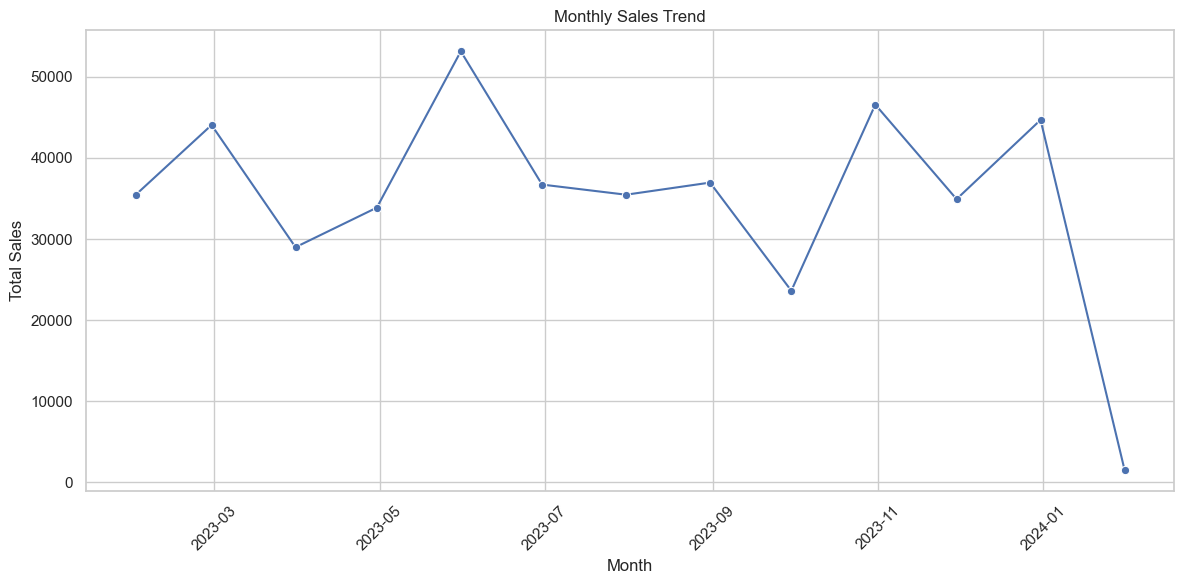

,Date,Total Amount
4,2023-05-31,53150
9,2023-10-31,46580
11,2023-12-31,44690
1,2023-02-28,44060
7,2023-08-31,36960


In [52]:
monthly_sales = (
    df.set_index(date_col)
      .resample("ME")[sales_col]
      .sum()
      .reset_index()
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_sales, x=date_col, y=sales_col, marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(monthly_sales.sort_values(sales_col, ascending=False).head())

**Observation:**  
The monthly sales chart shows whether the business is trending up, down, or showing seasonal cycles. Look for the strongest months and think about what might have caused them.

## 6. Time Series Analysis — Quarterly Sales Trend

This chart groups sales by quarter so we can see larger seasonal patterns and identify strong or weak quarters.

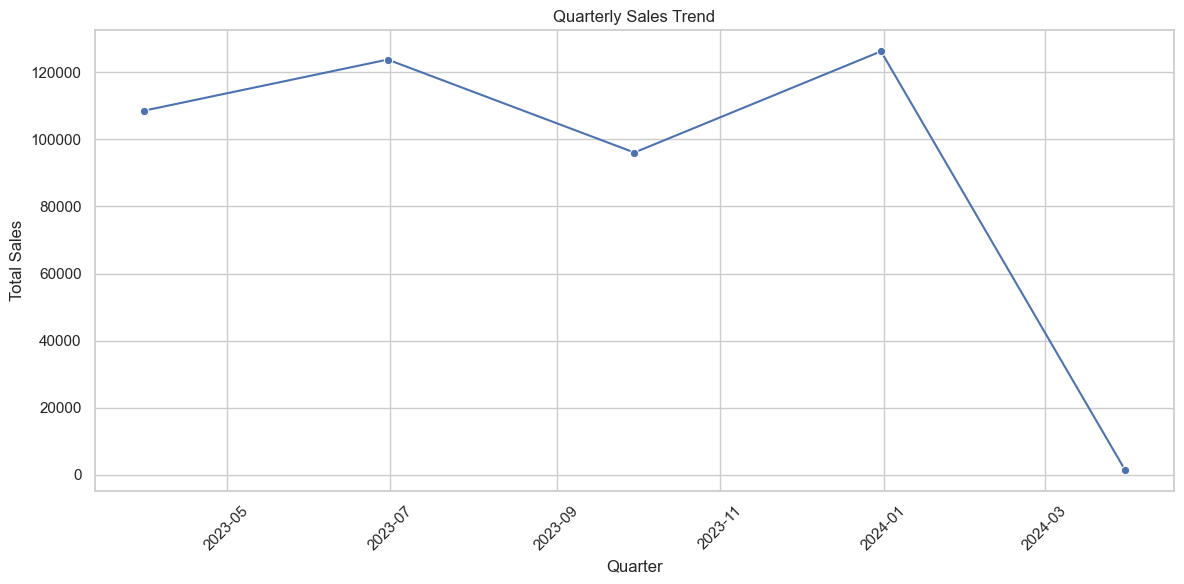

,Date,Total Amount
3,2023-12-31,126190
1,2023-06-30,123735
0,2023-03-31,108500
2,2023-09-30,96045
4,2024-03-31,1530


In [53]:
quarterly_sales = (
    df.set_index(date_col)
      .resample("QE")[sales_col]
      .sum()
      .reset_index()
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=quarterly_sales, x=date_col, y=sales_col, marker="o")
plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(quarterly_sales.sort_values(sales_col, ascending=False))

**Observation:**  
Quarterly sales give a wider view than monthly data and make it easier to spot strong or weak periods. This helps with planning inventory and marketing around the best-performing quarters.

## 7. Customer Demographics — Age Group Distribution

Customers are divided into age groups to understand which age segment contributes most to purchases.

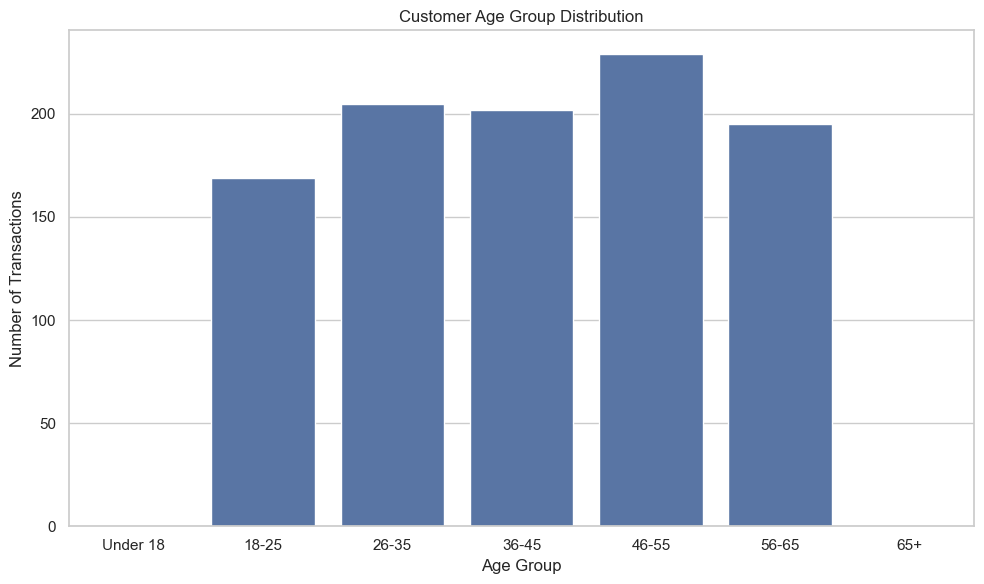

Age Group
Under 18      0
18-25       169
26-35       205
36-45       202
46-55       229
56-65       195
65+           0
Name: count, dtype: int64

In [54]:
if age_col is not None:
    age_bins = [0, 17, 25, 35, 45, 55, 65, 100]
    age_labels = ["Under 18", "18-25", "26-35", "36-45", "46-55", "56-65", "65+"]
    df["Age Group"] = pd.cut(df[age_col], bins=age_bins, labels=age_labels, right=True)

    age_group_counts = df["Age Group"].value_counts().sort_index()

    plt.figure(figsize=(10, 6))
    sns.barplot(x=age_group_counts.index.astype(str), y=age_group_counts.values)
    plt.title("Customer Age Group Distribution")
    plt.xlabel("Age Group")
    plt.ylabel("Number of Transactions")
    plt.tight_layout()
    plt.show()

    display(age_group_counts)
else:
    print("Age column not available in this dataset.")

**Observation:**  
The age group distribution helps identify the most active customer segment. The business can design targeted offers and product recommendations for the most frequent age group.

## 8. Customer Demographics — Gender Breakdown

This chart shows the gender-wise distribution of customers or transactions.

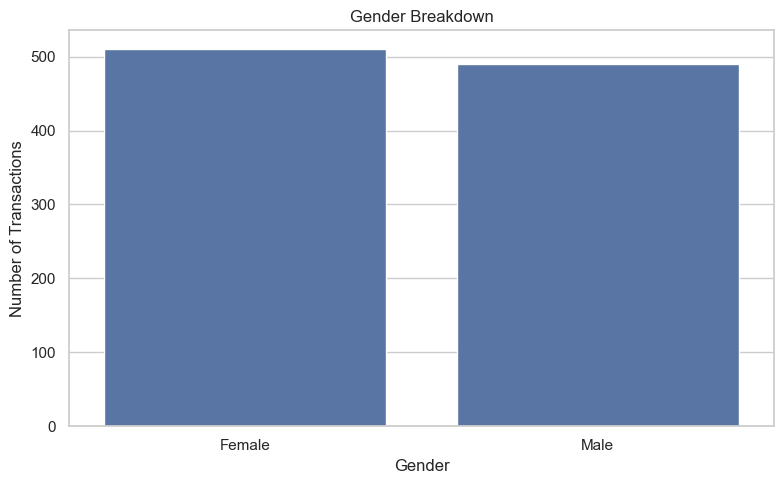

Gender
Female    510
Male      490
Name: count, dtype: int64

In [55]:
if gender_col is not None:
    gender_counts = df[gender_col].value_counts()

    plt.figure(figsize=(8, 5))
    sns.barplot(x=gender_counts.index, y=gender_counts.values)
    plt.title("Gender Breakdown")
    plt.xlabel("Gender")
    plt.ylabel("Number of Transactions")
    plt.tight_layout()
    plt.show()

    display(gender_counts)
else:
    print("Gender column not available in this dataset.")

**Observation:**  
Gender analysis shows whether purchases are balanced or concentrated among a particular gender group. This can guide personalised campaigns and product positioning.

## 9. Product Analysis — Top 10 Best-Selling Products

This analysis identifies the top products/categories by quantity sold.

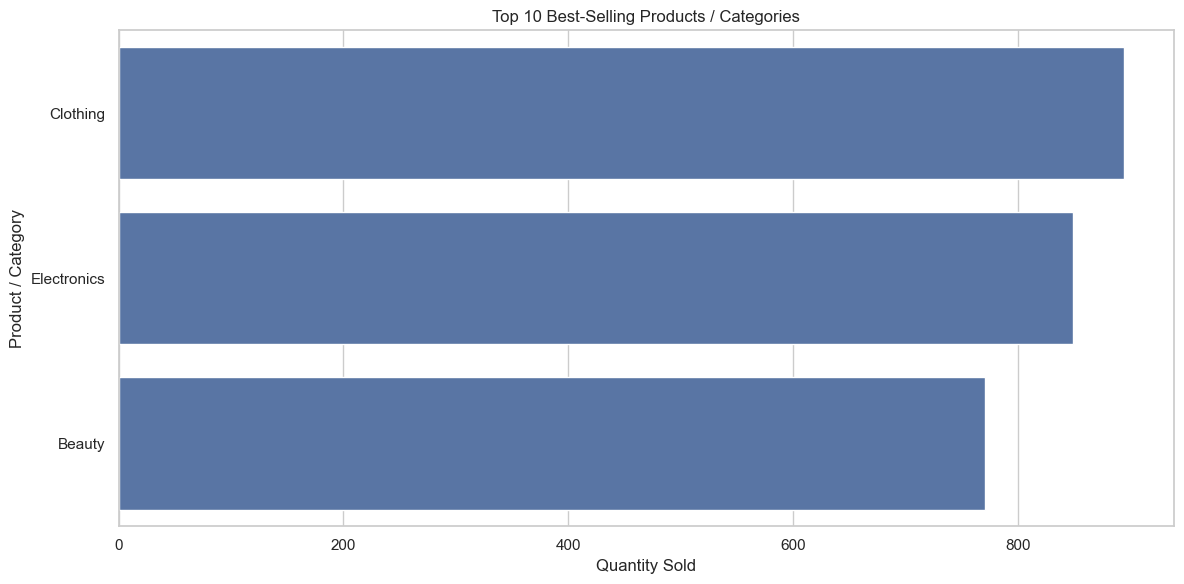

,Product Category,Quantity
0,Clothing,894
1,Electronics,849
2,Beauty,771


In [56]:
if product_col is not None:
    top_products = (
        df.groupby(product_col)[quantity_col]
          .sum()
          .sort_values(ascending=False)
          .head(10)
          .reset_index()
    )

    plt.figure(figsize=(12, 6))
    sns.barplot(data=top_products, x=quantity_col, y=product_col)
    plt.title("Top 10 Best-Selling Products / Categories")
    plt.xlabel("Quantity Sold")
    plt.ylabel("Product / Category")
    plt.tight_layout()
    plt.show()

    display(top_products)
else:
    print("Product or category column not available.")

**Observation:**  
Top-selling products/categories indicate the main demand drivers. These items should be prioritised for stock availability, promotions, and cross-selling strategies.

## 10. Product Analysis — Revenue by Product Category

This chart shows which product categories generate the highest revenue.

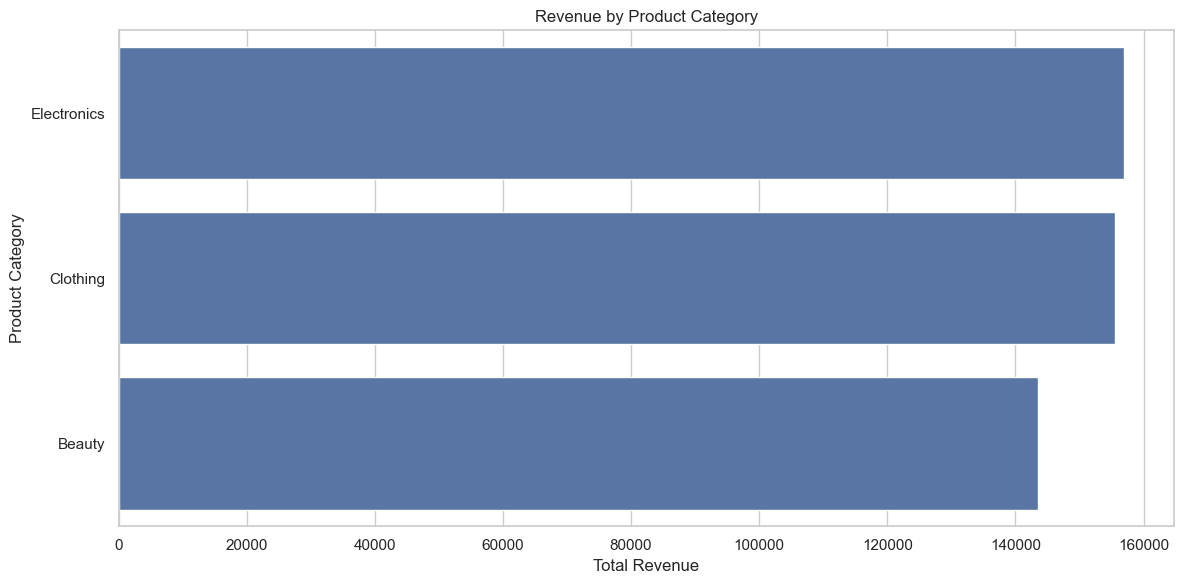

,Product Category,Total Amount
0,Electronics,156905
1,Clothing,155580
2,Beauty,143515


In [57]:
if category_col is not None:
    revenue_by_category = (
        df.groupby(category_col)[sales_col]
          .sum()
          .sort_values(ascending=False)
          .reset_index()
    )

    plt.figure(figsize=(12, 6))
    sns.barplot(data=revenue_by_category, x=sales_col, y=category_col)
    plt.title("Revenue by Product Category")
    plt.xlabel("Total Revenue")
    plt.ylabel("Product Category")
    plt.tight_layout()
    plt.show()

    display(revenue_by_category)
else:
    print("Category column not available.")

**Observation:**  
Revenue by category shows which categories contribute most to business income. A category may sell fewer units but still generate high revenue because of higher price per unit.

## 11. Correlation Heatmap

The correlation matrix shows relationships between numerical variables such as age, quantity, price, and sales.

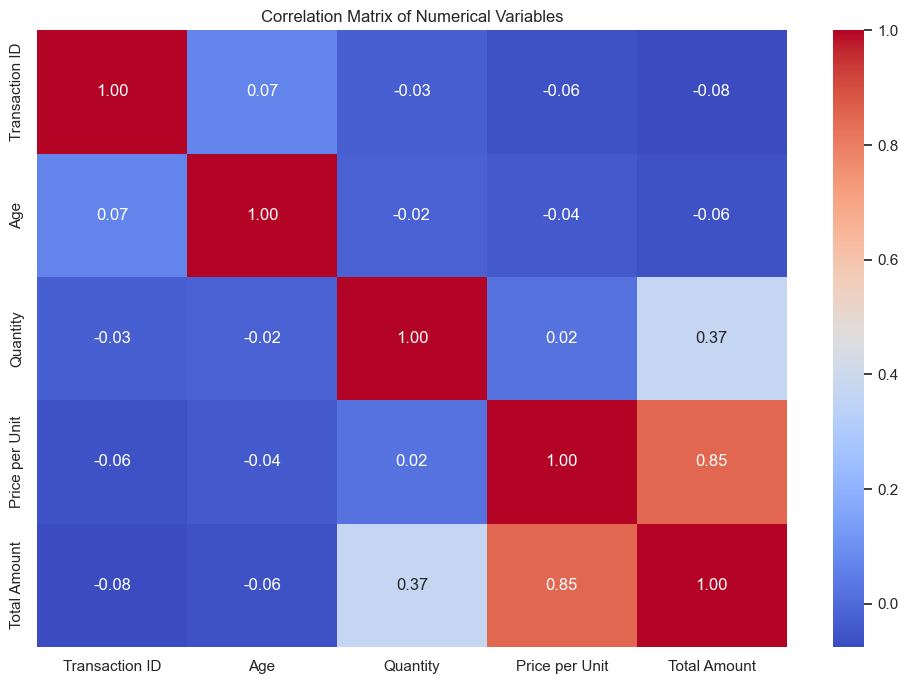

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
Transaction ID,1.00,0.07,-0.03,-0.06,-0.08
Age,0.07,1.00,-0.02,-0.04,-0.06
Quantity,-0.03,-0.02,1.00,0.02,0.37
Price per Unit,-0.06,-0.04,0.02,1.00,0.85
Total Amount,-0.08,-0.06,0.37,0.85,1.00


In [58]:
plt.figure(figsize=(10, 7))
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

display(corr_matrix)

**Observation:**  
The heatmap helps identify which numerical variables move together. For example, a strong positive correlation between quantity and total sales means higher quantities directly increase revenue.

## 12. Additional Visualisation — Average Sales by Age Group and Gender

This visualisation gives a deeper customer behaviour insight by comparing average spending across age groups and gender.

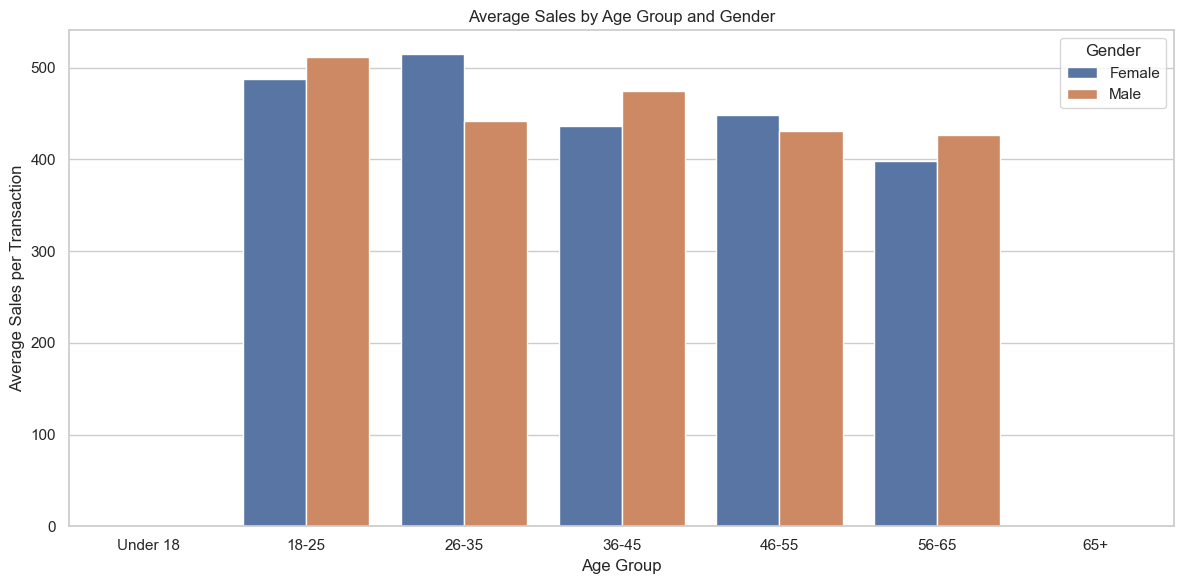

,Age Group,Gender,Total Amount
2,26-35,Female,515.09
1,18-25,Male,512.27
0,18-25,Female,487.28
5,36-45,Male,475.11
6,46-55,Female,447.98
3,26-35,Male,442.50
4,36-45,Female,436.78
7,46-55,Male,430.73
9,56-65,Male,426.26
8,56-65,Female,398.02


In [59]:
if age_col is not None and gender_col is not None:
    if "Age Group" not in df.columns:
        age_bins = [0, 17, 25, 35, 45, 55, 65, 100]
        age_labels = ["Under 18", "18-25", "26-35", "36-45", "46-55", "56-65", "65+"]
        df["Age Group"] = pd.cut(df[age_col], bins=age_bins, labels=age_labels, right=True)

    avg_sales_demo = (
        df.groupby(["Age Group", gender_col])[sales_col]
          .mean()
          .reset_index()
    )

    plt.figure(figsize=(12, 6))
    sns.barplot(data=avg_sales_demo, x="Age Group", y=sales_col, hue=gender_col)
    plt.title("Average Sales by Age Group and Gender")
    plt.xlabel("Age Group")
    plt.ylabel("Average Sales per Transaction")
    plt.tight_layout()
    plt.show()

    display(avg_sales_demo.sort_values(sales_col, ascending=False).head(10))
else:
    print("Age and/or gender column not available, so this visualisation cannot be generated.")

**Observation:**  
This chart reveals a more detailed customer insight than simple age or gender counts. A group with fewer transactions may still have higher average spending, making it valuable for premium offers and targeted marketing.

## 13. Key Insights Summary

Now we summarise the most important takeaways from the analysis.

In [ ]:
print("KEY INSIGHTS")

# Top month
if len(monthly_sales) > 0:
    top_month = monthly_sales.sort_values(sales_col, ascending=False).iloc[0]
    print(f"1. The highest monthly sales happened in {top_month[date_col].strftime('%B %Y')} with {top_month[sales_col]:,.2f}.")

# Top quarter
if len(quarterly_sales) > 0:
    top_quarter = quarterly_sales.sort_values(sales_col, ascending=False).iloc[0]
    if hasattr(top_quarter[date_col], 'quarter'):
        quarter_label = f"{top_quarter[date_col].year}-Q{top_quarter[date_col].quarter}"
    else:
        quarter_label = str(top_quarter[date_col])
    print(f"2. The strongest quarter was {quarter_label}, with {top_quarter[sales_col]:,.2f} in sales.")

# Top category
if category_col is not None:
    top_category = revenue_by_category.iloc[0]
    print(f"3. The top revenue category was {top_category[category_col]} with {top_category[sales_col]:,.2f} in sales.")

# Top product/category
if product_col is not None:
    top_item = top_products.iloc[0]
    print(f"4. The best-selling product or category was {top_item[product_col]}, with {top_item[quantity_col]:,.0f} units sold.")

# Top age group
if "Age Group" in df.columns:
    top_age = df["Age Group"].value_counts().idxmax()
    print(f"5. The most common customer age group is {top_age}.")

KEY INSIGHTS
1. Highest monthly sales occurred in May 2023 with sales of 53,150.00.
2. Highest quarterly sales occurred around 2023-Q4 with sales of 126,190.00.
3. Top revenue-generating category is Electronics with revenue of 156,905.00.
4. Best-selling product/category is Clothing with quantity sold of 894.
5. Most frequent customer age group is 46-55.


## 14. Conclusion and Actionable Business Recommendations

Based on the EDA, the following business recommendations can be made:

1. **Focus marketing campaigns on peak sales months/quarters.**  
   Since the time-series analysis identifies high-performing months or quarters, the business should launch major offers, festival sales, and ad campaigns during these periods to maximise revenue.

2. **Prioritise inventory for top-selling products/categories.**  
   The best-selling products and highest-revenue categories should be stocked in larger quantities to avoid stockouts and lost sales opportunities.

3. **Create targeted customer campaigns based on demographics.**  
   The age group and gender analysis can be used to design personalised discounts, product recommendations, and promotional messaging for the most active customer segments.

4. **Promote high-revenue categories through cross-selling.**  
   Categories with high revenue should be bundled with lower-performing categories to improve overall sales performance.

5. **Use customer spending patterns for premium offers.**  
   If a particular age/gender group has high average sales, the business can target that segment with premium products, loyalty benefits, and personalised recommendations.

## 15. Final Checklist

- [x] Loaded dataset and inspected shape, dtypes, null values  
- [x] Calculated descriptive statistics: mean, median, mode, standard deviation  
- [x] Plotted monthly sales trend  
- [x] Plotted quarterly sales trend  
- [x] Analysed customer age groups  
- [x] Analysed gender breakdown  
- [x] Found top 10 best-selling products/categories  
- [x] Visualised revenue by product category  
- [x] Created correlation heatmap  
- [x] Added one extra visualisation for deeper insight  
- [x] Added markdown observations  
- [x] Added conclusion and actionable recommendations